In [ ]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from statistics import mode
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import pandas as pd

Implementacja

In [ ]:
def euc_dist(x0, x1):
  dist = np.sqrt(np.sum((x0-x1)**2))
  return dist

#implementacja wykonana z pomoca poradnika z youtube
class KNN:
  def __init__(self, k_neighbors = 1, useKDTree = False):
    self.k_neighbors = k_neighbors
    self.useKDTree = useKDTree

  def fit(self, X, y):
    self.X_train = X
    self.y_train = y

  def predict(self, X):
    predictions = [self._predict(x) for x in X]
    return predictions

  def _predict(self, x):
    distances = [euc_dist(x, x_train) for x_train in self.X_train]

    indices = np.argsort(distances)[:self.k_neighbors]
    nearest_labels = [self.y_train[i] for i in indices]

    most_common = mode(nearest_labels)
    return most_common

  def predict_regression(self, X):
    predictions = [self._predict_regression(x) for x in X]
    return predictions

  def _predict_regression(self, x):
    distances = [euc_dist(x, x_train) for x_train in self.X_train]

    indices = np.argsort(distances)[:self.k_neighbors]
    nearest_labels = [self.y_train[i] for i in indices]

    mean = np.mean(nearest_labels)
    return mean

  def score(self, X, y):
    y_pred = self.predict(X)
    acc = np.sum(y_pred == y) / len(y)
    return acc

  def score_regression(self, X, y):
    y_pred = self.predict_regression(X)
    acc = mean_squared_error(y, y_pred)
    return acc

Klasyfikacja

In [33]:
X, y = datasets.make_classification(
      n_samples=100,
      n_features=2,
      n_informative=2,
      n_redundant=0,
      n_repeated=0,
      random_state=3
  )

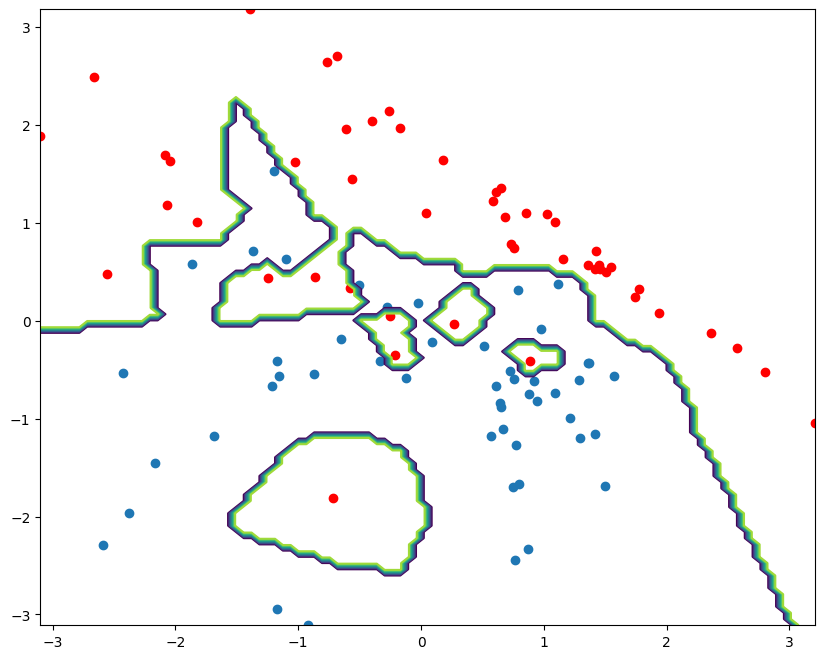

In [34]:
plt.figure(figsize=(10, 8))
plt.plot(X[:, 0][y==0], X[:, 1][y==0], 'o')
plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'ro')

knn = KNN(1)
knn.fit(X, y)
pr = knn.predict(X)
points = 100
xx, yy = np.meshgrid(np.linspace(np.min(X[:,0]), np.max(X[:, 0]), points), np.linspace(np.min(X[:, 1]), np.max(X[:, 1]), points))
dane = np.vstack([xx.ravel(), yy.ravel()]).T
pred = knn.predict(dane)
pred = np.array(pred).reshape(points, points)
plt.contour(xx, yy, pred)

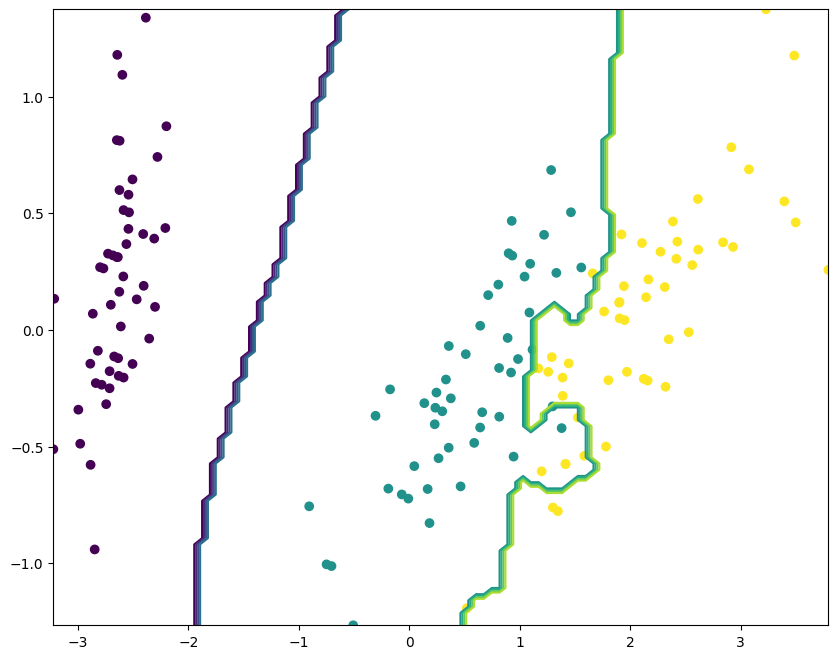

In [35]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)
knn = KNN(1)
knn.fit(X, y)
points=100
xx, yy = np.meshgrid(np.linspace(min(X_r[:, 0]), max(X_r[:, 0]), points), np.linspace(min(X_r[:, 1]),max(X_r[:, 1]), points)) #a
dane = np.vstack([xx.ravel(), yy.ravel()]).T
dane_r = pca.inverse_transform(dane) #b
pred = knn.predict(dane_r) #c
pred = np.array(pred).reshape(100, 100)
plt.figure(figsize=(10, 8))
plt.scatter(X_r[:, 0], X_r[:, 1], c=y)
plt.contour(xx, yy, pred)

In [36]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()

res = {'k': [], 'acc': []}
for k in range(1, 51):
  accs = []
  for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    knn = KNN(k)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    accs.append(acc)
  mean_accuracy = np.mean(accs)
  res['k'].append(k)
  res['acc'].append(mean_accuracy)

df = pd.DataFrame(res)
df

,k,acc
0,1,0.960000
1,2,0.960000
2,3,0.960000
3,4,0.960000
4,5,0.966667
5,6,0.960000
6,7,0.966667
7,8,0.966667
8,9,0.966667
9,10,0.953333


Regresja

<Figure size 1000x800 with 0 Axes>

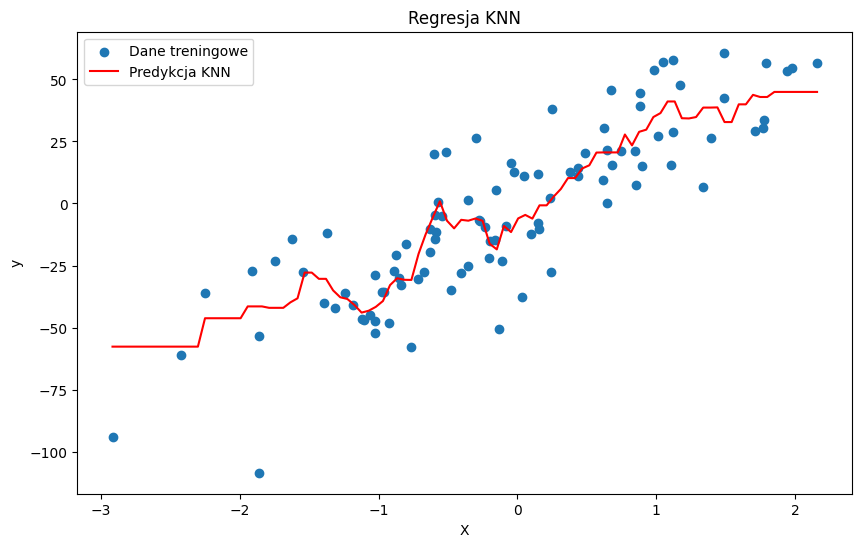

In [42]:
X, y = datasets.make_regression(
    n_samples = 100,
    n_features = 1,
    n_informative = 1,
    noise = 20,
    random_state = 3
)
knn = KNN(7)
knn.fit(X, y)
plt.figure(figsize=(10, 8))

n_points = 100
x_grid = np.linspace(min(X[:, 0]), max(X[:, 0]), n_points).reshape(-1, 1)
pred = np.array(knn.predict_regression(x_grid))

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, label='Dane treningowe')
plt.plot(x_grid[:, 0], pred, color='red', label='Predykcja KNN')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regresja KNN')
plt.legend()
plt.show()
